# PyMMM Pipeline: ND2 → Zarr

This notebook demonstrates the full PyMMM pipeline:
1. Load an ND2 file lazily
2. Register (drift-correct) the data
3. Detect feeding lanes
4. Detect trenches within lanes
5. Extract trenches to a compressed zarr store

Each stage checkpoints to a companion zarr store, so you can restart the kernel and resume from any checkpoint.

In [1]:
## enable jupyter autoreload magics
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
import os
sys.path.insert(0, "..")

In [3]:
from pymmm import ND2Experiment, Registrator, LaneDetector, TrenchDetector, Extractor
from pymmm.checkpoint import CompanionStore
from dask.distributed import Client, LocalCluster
import hvplot.xarray
import hvplot

hvplot.extension('bokeh')

# Start a dask cluster for parallelisation
cluster = LocalCluster(processes=True, threads_per_worker=1, n_workers=os.cpu_count())
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 61.91 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40249,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46393,Total threads: 1
Dashboard: http://127.0.0.1:37589/status,Memory: 1.93 GiB
Nanny: tcp://127.0.0.1:41877,


## 1. Load ND2 file

In [4]:
exp = ND2Experiment("/data/scientific_data/20260109_SB7_exit_snake.nd2") 
exp.select_times(0,750)

# Optional: crop to a spatial ROI
exp.select_roi(y=(570, 1000), x=(0, -1))

print(exp)

# Interactive browse raw data
exp.data.hvplot.image(
    x="X", y="Y", cmap="Greys_r", dynamic=True,
    rasterize=True, widget_location="top", aspect="equal"
)

ND2Experiment: 20260109_SB7_exit_snake
  Path: /data/scientific_data/20260109_SB7_exit_snake.nd2
  Dims: T=750 × P=36 × C=2 × Y=430 × X=1305
  FOVs: 36  (XYPos:0, XYPos:1, XYPos:2...)
  Channels: PC, mCherry
  Timepoints: 750
  Pixel size: 0.1079 µm
  Time interval: 30000.5 ms


Column
    [0] WidgetBox(align=('center', 'start'))
        [0] Select(name='P', options=[np.str_('XYPos:0'), ...], value=np.str_('XYPos:0'))
        [1] DiscreteSlider(name='T', options={'0': np.float64(0.0), ...}, value=np.float64(0.0))
        [2] Select(name='C', options=[np.str_('PC'), ...], value=np.str_('PC'))
    [1] HoloViews(DynamicMap, sizing_mode='fixed', widget_location='top')

In [7]:
# Optional: discard unwanted FOVs
# exp.discard_fovs(["xy029", "xy030"])

## 2. Companion store

In [9]:
store = CompanionStore.for_experiment(exp)
store

CompanionStore(/data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr, [empty])

## 3. Registration (Checkpoint 1)

Register the experiment to correct for stage drift.

In [ ]:
store.reset("registration")
if store.has_registration():
    print("Loading registration from checkpoint...")
    reg = Registrator.load(exp, store)
else:
    reg = Registrator(
        exp, store,
        registration_channel="PC",  # ← Change to your phase-contrast channel
        mode="first",
        rotation=0,               # ← Adjust rotation if needed
        roi={"y": (0, -1), "x": (0, -1)},
    )
    reg.compute_mean_images(plot=False)
    reg.compute_tmats(plot=True)  # n_jobs=-1 by default (all cores)
    reg.save()

No 'registration' section found — nothing to clear
Computing transformation matrices...


Registering FOVs:   0%|          | 0/36 [00:00<?, ?it/s]

  frames (XYPos:0):   0%|          | 0/750 [00:00<?, ?it/s]

  frames (XYPos:1):   0%|          | 0/750 [00:00<?, ?it/s]

In [28]:
# Interactive browse registered data
reg.get_stabilized_data().hvplot.image(
    x="X", y="Y", cmap="Greys_r", dynamic=True,
    rasterize=True, widget_location="top", aspect="equal"
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'44e23134-07be-4509-9613-762667692a40': {'version…

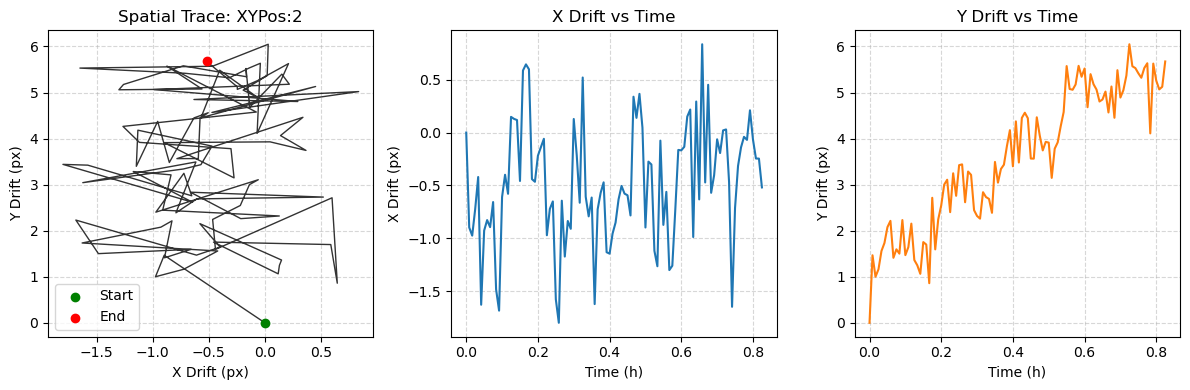

In [29]:
# Drift diagnostics for a specific FOV
reg.plot_drift(fov=2)

## 4. Lane Detection (Checkpoint 2)

Detect the feeding lane y-positions in each FOV.

In [12]:
#store.reset("lane_detection")
if store.has_lane_detection():
    print("Loading lane detection from checkpoint...")
    lane_det = LaneDetector.load(exp, reg, store)
else:
    lane_det = LaneDetector(exp, reg, store, detection_channel="PC")

In [18]:
# Tune sliders, browse FOVs, then click "Apply to all FOVs"
lane_det.interactive_detect_lanes()

In [14]:
# After tuning sliders and clicking "Apply to all FOVs", save the results
lane_det.save()

Lane detection saved to /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


In [16]:
# Inspect another FOV
# lane_det.plot_fov(fov=1)

## 5. Trench Detection (Checkpoint 3)

Detect trench x-positions within each lane.

In [19]:
#store.reset("trench_detection")
if store.has_trench_detection():
    print("Loading trench detection from checkpoint...")
    trench_det = TrenchDetector.load(exp, reg, lane_det, store)
else:
    trench_det = TrenchDetector(exp, reg, lane_det, store, detection_channel="PC")

Loading trench detection from checkpoint...


In [20]:
# Tune sliders, browse FOVs, then click "Apply to all FOVs"
trench_det.interactive_detect_trenches()

In [21]:
# After tuning sliders and clicking "Apply to all FOVs", save the results
trench_det.save()

Trench detection saved to /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


In [22]:
# Trench table
trench_det.get_trench_table()

,trench_id,fov,lane_index,x_left,x_right,y_top,y_bottom,orientation,needs_flip
0,0,XYPos:0,0,44,76,623,823,1,False
1,1,XYPos:0,0,89,121,623,823,1,False
2,2,XYPos:0,0,135,167,623,823,1,False
3,3,XYPos:0,0,180,212,623,823,1,False
4,4,XYPos:0,0,226,258,623,823,1,False
...,...,...,...,...,...,...,...,...,...
80,80,XYPos:2,0,1089,1121,629,829,1,False
81,81,XYPos:2,0,1135,1167,629,829,1,False
82,82,XYPos:2,0,1179,1211,629,829,1,False
83,83,XYPos:2,0,1224,1256,629,829,1,False


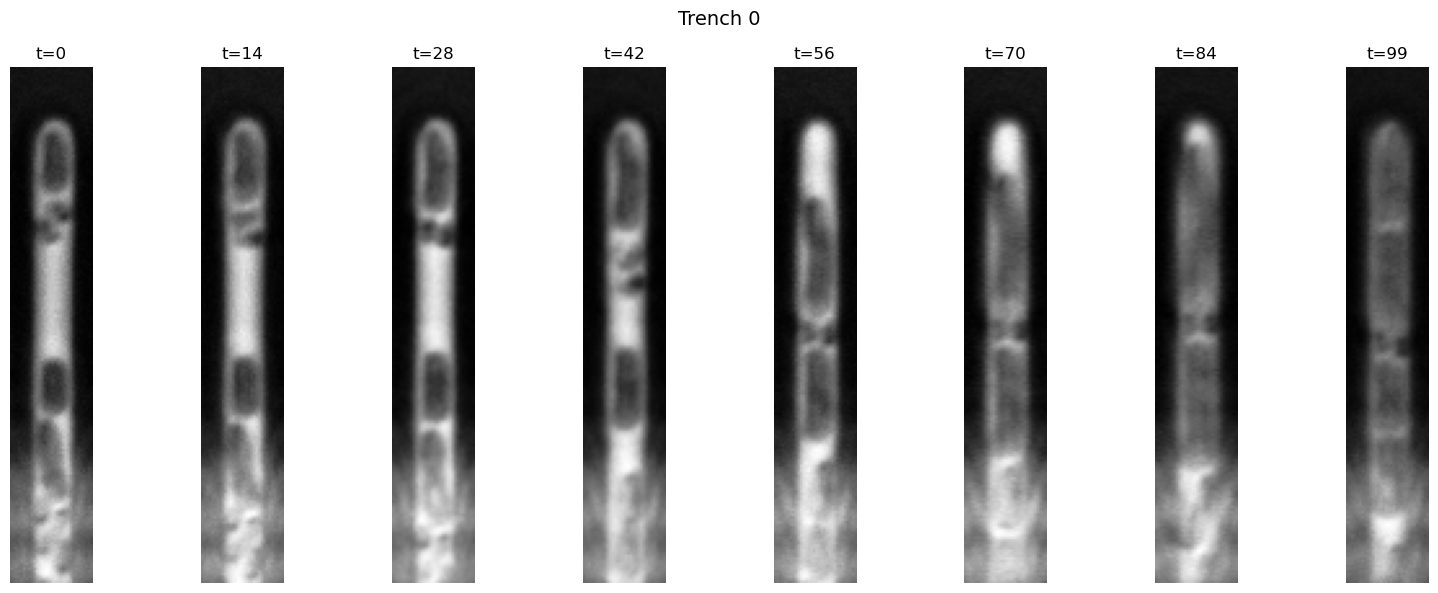

In [23]:
# Preview a single trench before full extraction
from pymmm.plotting import plot_trench_preview
preview = trench_det_extractor_preview = Extractor(exp, reg, trench_det)
single = preview.extract_single_trench(trench_id=0)
plot_trench_preview(single, trench_id=0, n_frames=8)

## 6. Extraction

Extract all trenches to a compressed zarr store.

In [26]:
extractor = Extractor(exp, reg, trench_det)
extractor.extract(compressor='zstd', clevel=9, show_progress=True)

Extracting FOVs:   0%|          | 0/3 [00:00<?, ?it/s]

Extraction complete: /data/scientific_data/20260109_SB7_exit_snake.trenches.zarr
  Shape: (85, 100, 2, 200, 32), Chunks: (1, 100, 1, 200, 32)


## 7. Verify output

In [ ]:
import zarr

z = zarr.open(str(extractor.output_path), mode='r')
print("Shape:", z['data'].shape)
print("Chunks:", z['data'].chunks)
print("Attrs:", dict(z.attrs))